# Probability & Statistics for Computer Vision

## Course Overview
This notebook covers fundamental probability and statistics concepts essential for computer vision, with focus on image analysis, histogram processing, and threshold techniques.

**Learning Objectives:**
- Understand probability distributions and their properties
- Master Gaussian distribution and Bayes' theorem
- Learn image histograms and statistical analysis
- Apply histogram equalization and CLAHE
- Implement Otsu's thresholding algorithm
- Build complete demos for image enhancement and segmentation

---
# PART 1: MORNING (AM) - PROBABILITY FUNDAMENTALS & DISTRIBUTIONS
---

## 1. Setup & Libraries

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
from scipy import stats
from scipy.ndimage import gaussian_filter
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.set_printoptions(precision=4, suppress=True)

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
# print(f"SciPy version: {stats.__version__}")

Libraries loaded successfully!
NumPy version: 2.4.0
OpenCV version: 4.13.0


## 2. Probability Fundamentals

### Basic Concepts
**Probability:** Measure of likelihood that an event will occur.
- Range: 0 ≤ P(X) ≤ 1
- P(X) = 0: Event never happens
- P(X) = 1: Event always happens

### Probability Distribution
A function that describes the likelihood of different outcomes in a random variable.

**PDF (Probability Density Function):**
$$p(x) \geq 0, \quad \int_{-\infty}^{\infty} p(x)dx = 1$$

**CDF (Cumulative Distribution Function):**
$$F(x) = P(X \leq x) = \int_{-\infty}^{x} p(t)dt$$

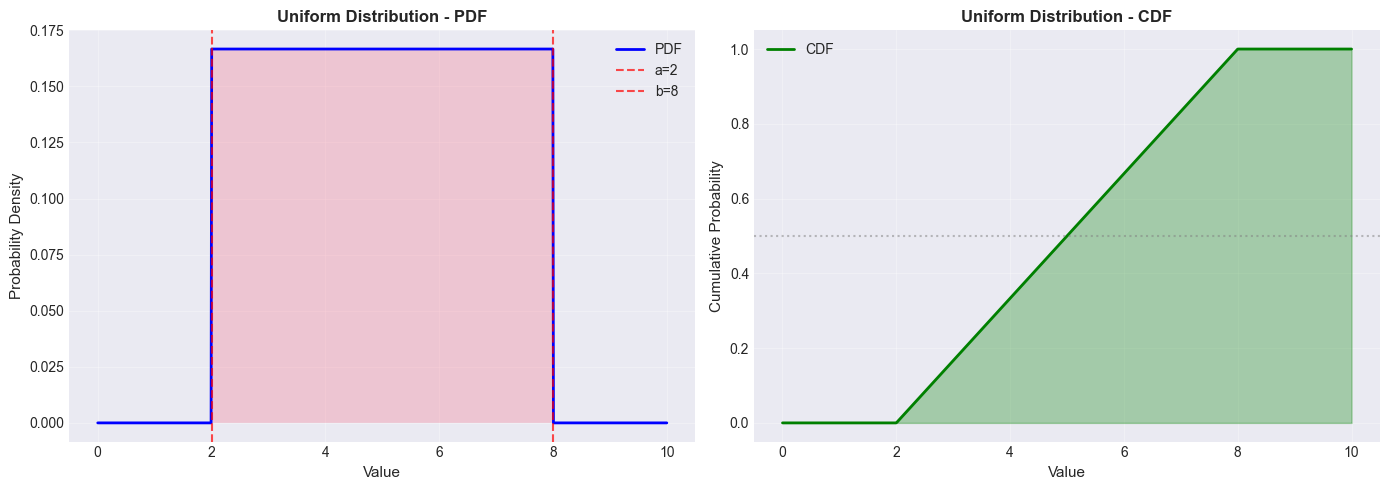

Uniform Distribution Properties:
Mean (expected value): 5.0000
Variance: 3.0000
Standard deviation: 1.7321
P(X ≤ 5): 0.5000


In [14]:
# Continuous uniform distribution
x = np.linspace(0, 10, 1000)
uniform_dist = stats.uniform(loc=2, scale=6)  # Uniform from 2 to 8

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF
ax = axes[0]
ax.plot(x, uniform_dist.pdf(x), 'b-', linewidth=2, label='PDF')
ax.fill_between(x, uniform_dist.pdf(x), alpha=0.3)
ax.axvline(2, color='r', linestyle='--', alpha=0.7, label='a=2')
ax.axvline(8, color='r', linestyle='--', alpha=0.7, label='b=8')
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('Uniform Distribution - PDF', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# CDF
ax = axes[1]
ax.plot(x, uniform_dist.cdf(x), 'g-', linewidth=2, label='CDF')
ax.fill_between(x, uniform_dist.cdf(x), alpha=0.3, color='green')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Cumulative Probability', fontsize=11)
ax.set_title('Uniform Distribution - CDF', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Uniform Distribution Properties:")
print(f"Mean (expected value): {uniform_dist.mean():.4f}")
print(f"Variance: {uniform_dist.var():.4f}")
print(f"Standard deviation: {uniform_dist.std():.4f}")
print(f"P(X ≤ 5): {uniform_dist.cdf(5):.4f}")

## 3. Gaussian (Normal) Distribution

### Most Important Distribution in Statistics & CV

**PDF:**
$$p(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Where:
- **μ (mu):** Mean - center of distribution
- **σ (sigma):** Standard deviation - spread/width
- **σ²:** Variance

### Properties
- **Bell-shaped** and **symmetric** around mean
- **68-95-99.7 rule:** 68% within 1σ, 95% within 2σ, 99.7% within 3σ
- **Ubiquitous** in natural phenomena and image noise

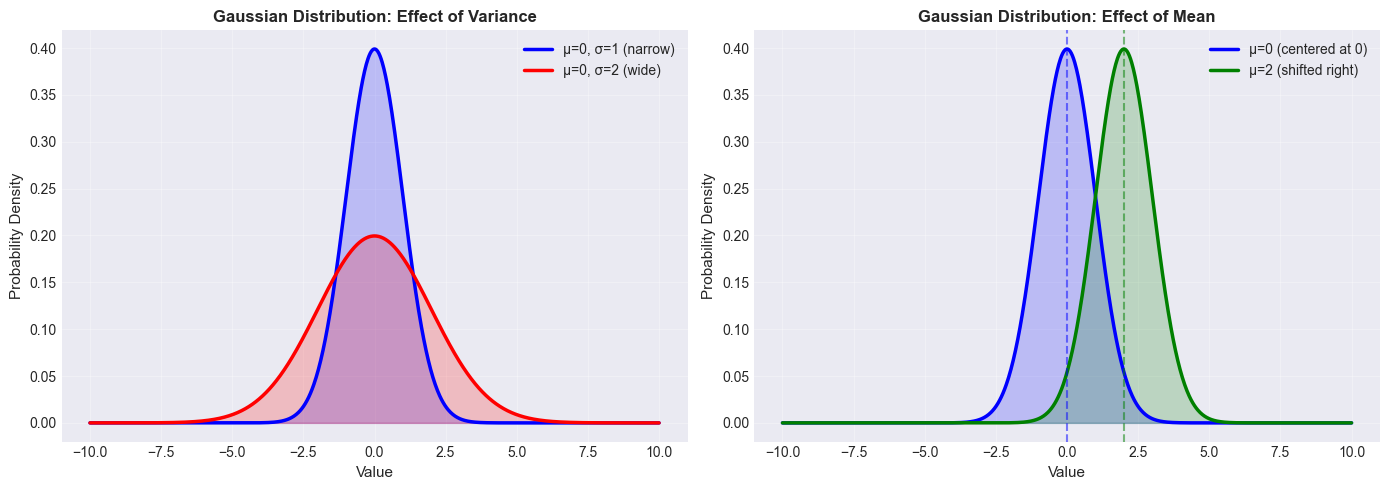

Standard Normal Distribution (μ=0, σ=1):
P(X ≤ 0) = 0.5000
P(-1 ≤ X ≤ 1) = 0.6827 (68.27%)
P(-2 ≤ X ≤ 2) = 0.9545 (95.45%)
P(-3 ≤ X ≤ 3) = 0.9973 (99.73%)


In [15]:
# Create Gaussian distributions with different parameters
x = np.linspace(-10, 10, 1000)

# Different Gaussian distributions
gaussian1 = stats.norm(loc=0, scale=1)    # μ=0, σ=1 (standard normal)
gaussian2 = stats.norm(loc=0, scale=2)    # μ=0, σ=2 (wider)
gaussian3 = stats.norm(loc=2, scale=1)    # μ=2, σ=1 (shifted)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effect of variance
ax = axes[0]
ax.plot(x, gaussian1.pdf(x), 'b-', linewidth=2.5, label='μ=0, σ=1 (narrow)')
ax.fill_between(x, gaussian1.pdf(x), alpha=0.2, color='blue')
ax.plot(x, gaussian2.pdf(x), 'r-', linewidth=2.5, label='μ=0, σ=2 (wide)')
ax.fill_between(x, gaussian2.pdf(x), alpha=0.2, color='red')
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('Gaussian Distribution: Effect of Variance', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Effect of mean
ax = axes[1]
ax.plot(x, gaussian1.pdf(x), 'b-', linewidth=2.5, label='μ=0 (centered at 0)')
ax.fill_between(x, gaussian1.pdf(x), alpha=0.2, color='blue')
ax.plot(x, gaussian3.pdf(x), 'g-', linewidth=2.5, label='μ=2 (shifted right)')
ax.fill_between(x, gaussian3.pdf(x), alpha=0.2, color='green')
ax.axvline(0, color='b', linestyle='--', alpha=0.5)
ax.axvline(2, color='g', linestyle='--', alpha=0.5)
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('Gaussian Distribution: Effect of Mean', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Standard Normal Distribution (μ=0, σ=1):")
print(f"P(X ≤ 0) = {gaussian1.cdf(0):.4f}")
print(f"P(-1 ≤ X ≤ 1) = {gaussian1.cdf(1) - gaussian1.cdf(-1):.4f} (68.27%)")
print(f"P(-2 ≤ X ≤ 2) = {gaussian1.cdf(2) - gaussian1.cdf(-2):.4f} (95.45%)")
print(f"P(-3 ≤ X ≤ 3) = {gaussian1.cdf(3) - gaussian1.cdf(-3):.4f} (99.73%)")

### 2D Gaussian Distribution (Multivariate)
Essential for image processing and feature distributions.

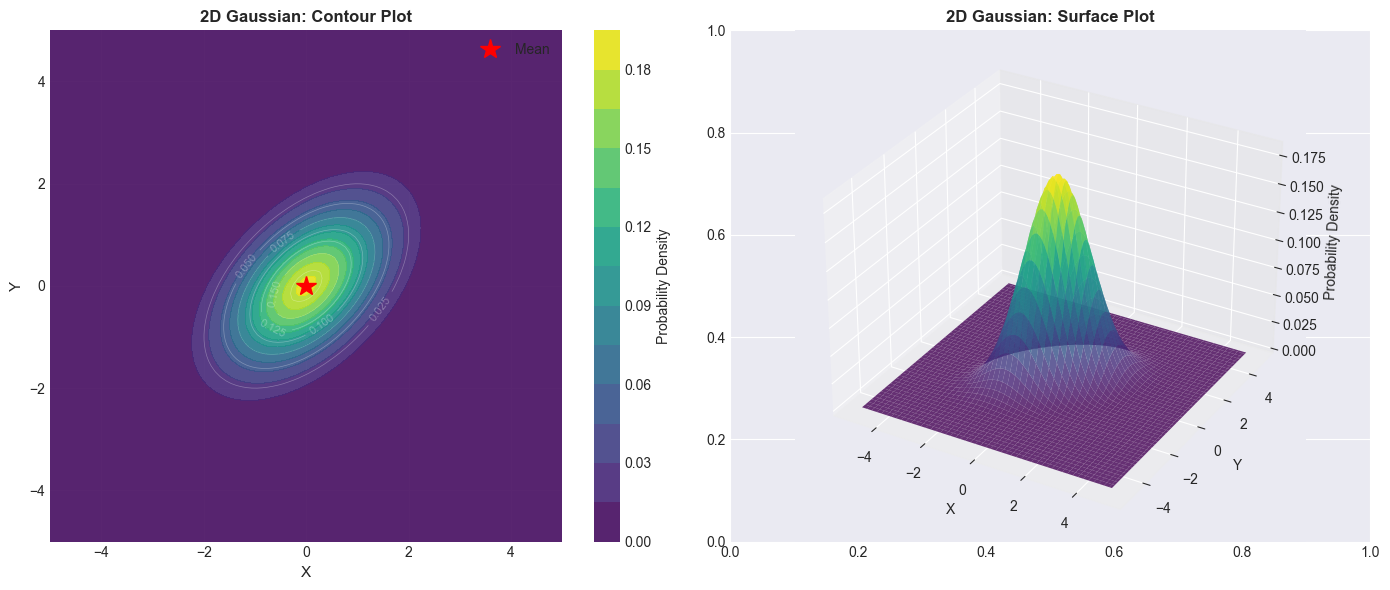

Bivariate Gaussian Properties:
Mean: [0. 0.]
Covariance matrix:
[[1.  0.5]
 [0.5 1. ]]
Correlation between X and Y: 0.5


In [16]:
# Create 2D Gaussian
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# Bivariate Gaussian with correlation
mu = [0, 0]
sigma = [[1, 0.5], [0.5, 1]]  # Covariance matrix with correlation

# Calculate bivariate normal PDF
pos = np.dstack((X, Y))
bivariate = stats.multivariate_normal(mean=mu, cov=sigma)
Z = bivariate.pdf(pos)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3D surface
ax = axes[0]
contour = ax.contourf(X, Y, Z, levels=15, cmap='viridis', alpha=0.9)
contour_lines = ax.contour(X, Y, Z, levels=8, colors='white', alpha=0.3, linewidths=0.5)
ax.clabel(contour_lines, inline=True, fontsize=8)
ax.plot(0, 0, 'r*', markersize=15, label='Mean')
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)
ax.set_title('2D Gaussian: Contour Plot', fontsize=12, fontweight='bold')
ax.legend()
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Probability Density', fontsize=10)

# 3D surface plot
from mpl_toolkits.mplot3d import Axes3D
ax = plt.subplot(1, 2, 2, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax.set_xlabel('X', fontsize=10)
ax.set_ylabel('Y', fontsize=10)
ax.set_zlabel('Probability Density', fontsize=10)
ax.set_title('2D Gaussian: Surface Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Bivariate Gaussian Properties:")
print(f"Mean: {bivariate.mean}")
print(f"Covariance matrix:\n{bivariate.cov}")
print(f"Correlation between X and Y: 0.5")

## 4. Bayes' Theorem

### Foundation of Probabilistic Reasoning

**Mathematical Formula:**
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Where:
- **P(A|B):** Posterior probability (what we want to find)
- **P(B|A):** Likelihood (probability of evidence given hypothesis)
- **P(A):** Prior probability (initial belief)
- **P(B):** Evidence (normalizing constant)

### In Machine Learning & CV
$$P(\text{Class}|\text{Features}) = \frac{P(\text{Features}|\text{Class}) \cdot P(\text{Class})}{P(\text{Features})}$$

In [17]:
# Example: Disease Testing
print("BAYES' THEOREM EXAMPLE: Medical Testing")
print("="*60)
print()

# Given information
disease_prevalence = 0.01  # 1% of population has disease
test_sensitivity = 0.99    # Test is positive 99% when disease present
test_specificity = 0.95    # Test is negative 95% when disease absent

# P(Disease) and P(No Disease)
p_disease = disease_prevalence
p_no_disease = 1 - disease_prevalence

# P(Positive|Disease) and P(Positive|No Disease)
p_positive_given_disease = test_sensitivity
p_positive_given_no_disease = 1 - test_specificity  # False positive rate

# P(Positive) - total probability
p_positive = (p_positive_given_disease * p_disease + 
              p_positive_given_no_disease * p_no_disease)

# P(Disease|Positive) - Bayes' theorem
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print("Given Information:")
print(f"  Disease prevalence (prior): {p_disease*100:.1f}%")
print(f"  Test sensitivity: {test_sensitivity*100:.1f}%")
print(f"  Test specificity: {test_specificity*100:.1f}%")
print()

print("Calculations:")
print(f"  P(Positive|Disease) = {p_positive_given_disease:.4f}")
print(f"  P(Positive|No Disease) = {p_positive_given_no_disease:.4f}")
print(f"  P(Positive) = {p_positive:.4f}")
print()

print(f"Result:")
print(f"  P(Disease|Positive test) = {p_disease_given_positive:.4f}")
print(f"  If test is positive, probability of disease: {p_disease_given_positive*100:.2f}%")
print()
print("Key Insight: High test accuracy doesn't mean high probability!")
print("The prior probability matters greatly.")

BAYES' THEOREM EXAMPLE: Medical Testing

Given Information:
  Disease prevalence (prior): 1.0%
  Test sensitivity: 99.0%
  Test specificity: 95.0%

Calculations:
  P(Positive|Disease) = 0.9900
  P(Positive|No Disease) = 0.0500
  P(Positive) = 0.0594

Result:
  P(Disease|Positive test) = 0.1667
  If test is positive, probability of disease: 16.67%

Key Insight: High test accuracy doesn't mean high probability!
The prior probability matters greatly.


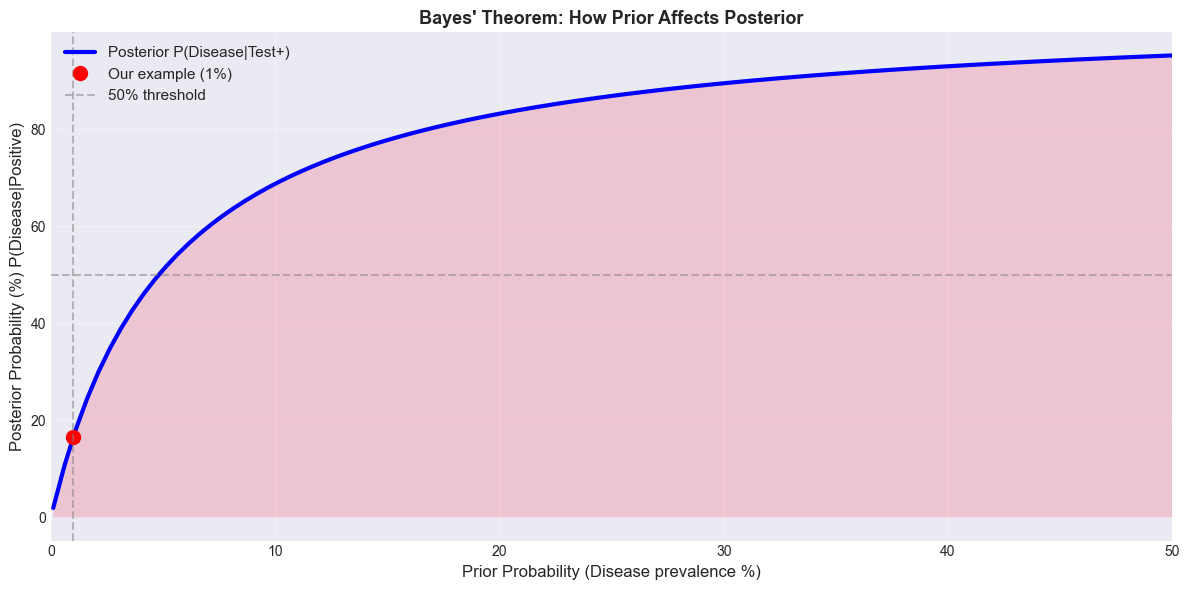

In [18]:
# Visualize Bayes' theorem impact
priors = np.linspace(0.001, 0.5, 100)
posteriors = []

for prior in priors:
    p_pos = (test_sensitivity * prior + p_positive_given_no_disease * (1 - prior))
    posterior = (test_sensitivity * prior) / p_pos
    posteriors.append(posterior)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(priors * 100, np.array(posteriors) * 100, 'b-', linewidth=3, label="Posterior P(Disease|Test+)")
ax.fill_between(priors * 100, 0, np.array(posteriors) * 100, alpha=0.3)

# Mark our example
ax.plot(disease_prevalence * 100, p_disease_given_positive * 100, 'ro', markersize=10, label="Our example (1%)")
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label="50% threshold")
ax.axvline(x=disease_prevalence * 100, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Prior Probability (Disease prevalence %)', fontsize=12)
ax.set_ylabel('Posterior Probability (%) P(Disease|Positive)', fontsize=12)
ax.set_title("Bayes' Theorem: How Prior Affects Posterior", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim(0, 50)

plt.tight_layout()
plt.show()

## 5. Histograms & Image Statistics

### What is a Histogram?
A histogram is a graphical representation of the distribution of pixel values in an image.

For 8-bit images:
- **X-axis:** Pixel intensity (0-255)
- **Y-axis:** Frequency (number of pixels with that intensity)
- **Total:** Sum of all bins = total number of pixels

### Types
- **Grayscale histogram:** Single histogram of intensities
- **Color histogram:** Separate histograms for R, G, B channels

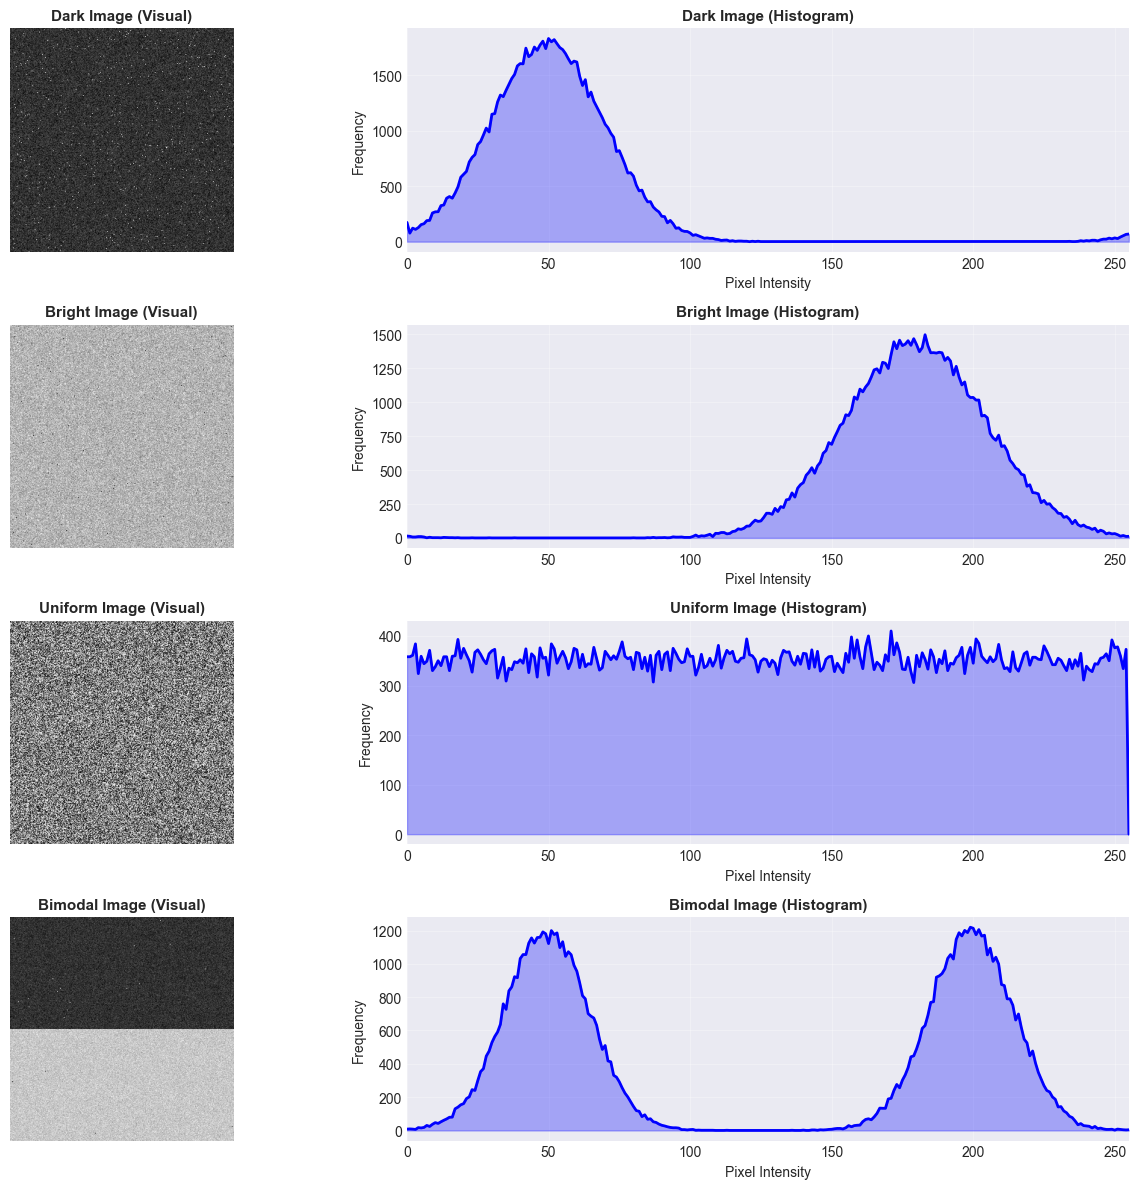

Image Statistics:

Dark Image:
  Mean: 50.95
  Median: 50.00
  Std Dev: 24.52
  Min: 0, Max: 255

Bright Image:
  Mean: 179.28
  Median: 179.00
  Std Dev: 25.45
  Min: 0, Max: 255

Uniform Image:
  Mean: 126.97
  Median: 127.00
  Std Dev: 73.59
  Min: 0, Max: 254

Bimodal Image:
  Mean: 124.48
  Median: 146.00
  Std Dev: 76.45
  Min: 0, Max: 255



In [19]:
# Create a sample image with known distribution
np.random.seed(42)

# Create image with Gaussian-like distribution
image_dark = np.random.normal(50, 20, (300, 300)).astype(np.uint8)
image_bright = np.random.normal(180, 25, (300, 300)).astype(np.uint8)
image_uniform = np.random.uniform(0, 255, (300, 300)).astype(np.uint8)
image_bimodal = np.concatenate([np.random.normal(50, 15, (300*150,)), 
                                 np.random.normal(200, 15, (300*150,))]).astype(np.uint8)
image_bimodal = image_bimodal.reshape(300, 300)

# Calculate histograms
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

images = [image_dark, image_bright, image_uniform, image_bimodal]
titles = ["Dark Image", "Bright Image", "Uniform Image", "Bimodal Image"]

for idx, (img, title) in enumerate(zip(images, titles)):
    # Image
    ax = axes[idx, 0]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{title} (Visual)", fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # Histogram
    ax = axes[idx, 1]
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    ax.plot(hist, color='blue', linewidth=2)
    ax.fill_between(range(256), hist.flatten(), alpha=0.3, color='blue')
    ax.set_title(f"{title} (Histogram)", fontsize=11, fontweight='bold')
    ax.set_xlabel('Pixel Intensity', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()

print("Image Statistics:")
print()
for img, title in zip(images, titles):
    print(f"{title}:")
    print(f"  Mean: {np.mean(img):.2f}")
    print(f"  Median: {np.median(img):.2f}")
    print(f"  Std Dev: {np.std(img):.2f}")
    print(f"  Min: {np.min(img)}, Max: {np.max(img)}")
    print()

### Histogram Statistics
Statistical measures extracted from histograms.

In [20]:
# Detailed histogram statistics
img = image_dark.copy()
hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()

# Normalize to probability distribution
prob_dist = hist / np.sum(hist)

# Calculate statistics
intensities = np.arange(0, 256)

# Mean (first moment)
mean = np.sum(intensities * prob_dist)

# Variance (second moment)
variance = np.sum((intensities - mean)**2 * prob_dist)
std_dev = np.sqrt(variance)

# Skewness (third moment) - asymmetry
skewness = np.sum(((intensities - mean)/std_dev)**3 * prob_dist)

# Kurtosis (fourth moment) - tail behavior
kurtosis = np.sum(((intensities - mean)/std_dev)**4 * prob_dist) - 3

# Entropy - information content
entropy = -np.sum(prob_dist[prob_dist > 0] * np.log2(prob_dist[prob_dist > 0]))

print("HISTOGRAM STATISTICS")
print("="*50)
print()
print("For Dark Image:")
print(f"Mean intensity: {mean:.2f}")
print(f"Standard deviation: {std_dev:.2f}")
print(f"Skewness: {skewness:.4f}")
print(f"  (negative = tail to left, positive = tail to right)")
print(f"Kurtosis: {kurtosis:.4f}")
print(f"  (measure of tail heaviness)")
print(f"Entropy: {entropy:.4f} bits")
print(f"  (maximum entropy for uniform = {np.log2(256):.2f} bits)")
print()
print("Interpretation:")
print(f"- Entropy {entropy:.2f} means {entropy/np.log2(256)*100:.1f}% of max information")
print(f"- Skewness {skewness:.2f} shows {('left-skewed' if skewness < 0 else 'right-skewed')}")

HISTOGRAM STATISTICS

For Dark Image:
Mean intensity: 50.95
Standard deviation: 24.52
Skewness: 2.8909
  (negative = tail to left, positive = tail to right)
Kurtosis: 21.8952
  (measure of tail heaviness)
Entropy: 6.3678 bits
  (maximum entropy for uniform = 8.00 bits)

Interpretation:
- Entropy 6.37 means 79.6% of max information
- Skewness 2.89 shows right-skewed


---
# PART 2: AFTERNOON (PM) - IMAGE HISTOGRAMS & ENHANCEMENT
---

## 6. Image Histograms in OpenCV

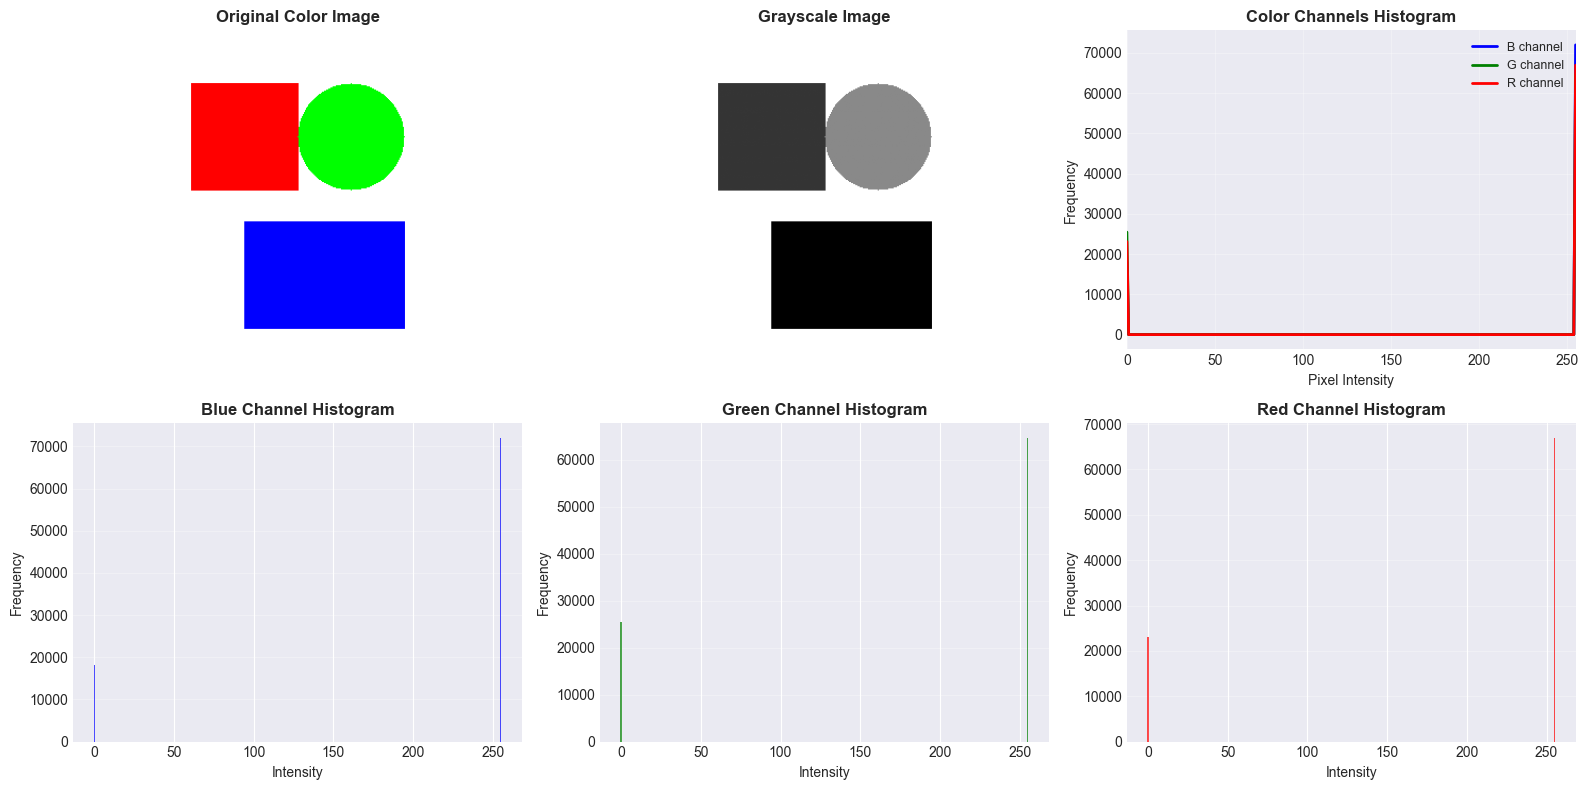

Histogram calculation using OpenCV:
Histogram shape: (256, 1)
Total pixels: 90000.0
Non-zero bins: 2


In [21]:
# Create a more realistic test image
test_image = np.ones((300, 300, 3), dtype=np.uint8) * 255  # White background

# Add various elements with different colors
cv2.rectangle(test_image, (50, 50), (150, 150), (0, 0, 255), -1)      # Red square
cv2.circle(test_image, (200, 100), 50, (0, 255, 0), -1)               # Green circle
cv2.rectangle(test_image, (100, 180), (250, 280), (255, 0, 0), -1)   # Blue rectangle

# Convert to grayscale for histogram
img_gray = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)

# Calculate histograms for each channel
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Original image (BGR)
ax = axes[0, 0]
ax.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
ax.set_title('Original Color Image', fontsize=12, fontweight='bold')
ax.axis('off')

# Grayscale image
ax = axes[0, 1]
ax.imshow(img_gray, cmap='gray')
ax.set_title('Grayscale Image', fontsize=12, fontweight='bold')
ax.axis('off')

# Combined color histogram
ax = axes[0, 2]
colors = ('b', 'g', 'r')
for i, color in enumerate(colors):
    hist = cv2.calcHist([test_image], [i], None, [256], [0, 256])
    ax.plot(hist, color=color, linewidth=2, label=f'{color.upper()} channel')
ax.set_title('Color Channels Histogram', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 255)

# Blue channel histogram
ax = axes[1, 0]
hist_b = cv2.calcHist([test_image], [0], None, [256], [0, 256])
ax.bar(range(256), hist_b.flatten(), color='blue', alpha=0.7)
ax.set_title('Blue Channel Histogram', fontsize=12, fontweight='bold')
ax.set_xlabel('Intensity')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# Green channel histogram
ax = axes[1, 1]
hist_g = cv2.calcHist([test_image], [1], None, [256], [0, 256])
ax.bar(range(256), hist_g.flatten(), color='green', alpha=0.7)
ax.set_title('Green Channel Histogram', fontsize=12, fontweight='bold')
ax.set_xlabel('Intensity')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# Red channel histogram
ax = axes[1, 2]
hist_r = cv2.calcHist([test_image], [2], None, [256], [0, 256])
ax.bar(range(256), hist_r.flatten(), color='red', alpha=0.7)
ax.set_title('Red Channel Histogram', fontsize=12, fontweight='bold')
ax.set_xlabel('Intensity')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Histogram calculation using OpenCV:")
print(f"Histogram shape: {hist_b.shape}")
print(f"Total pixels: {np.sum(hist_b)}")
print(f"Non-zero bins: {np.count_nonzero(hist_b)}")

## 7. Histogram Equalization

### Purpose
Enhance image contrast by redistributing pixel intensities uniformly across the full range [0, 255].

### Process
1. Calculate histogram of original image
2. Compute cumulative distribution function (CDF)
3. Normalize CDF to range [0, 255]
4. Map each pixel: new_pixel = floor(CDF_normalized[old_pixel])

### Benefits
- Increases contrast
- Improves visibility of details
- Makes histogram more uniform

### Drawbacks
- Can amplify noise
- May over-enhance uniform regions
- Can create unnatural-looking images

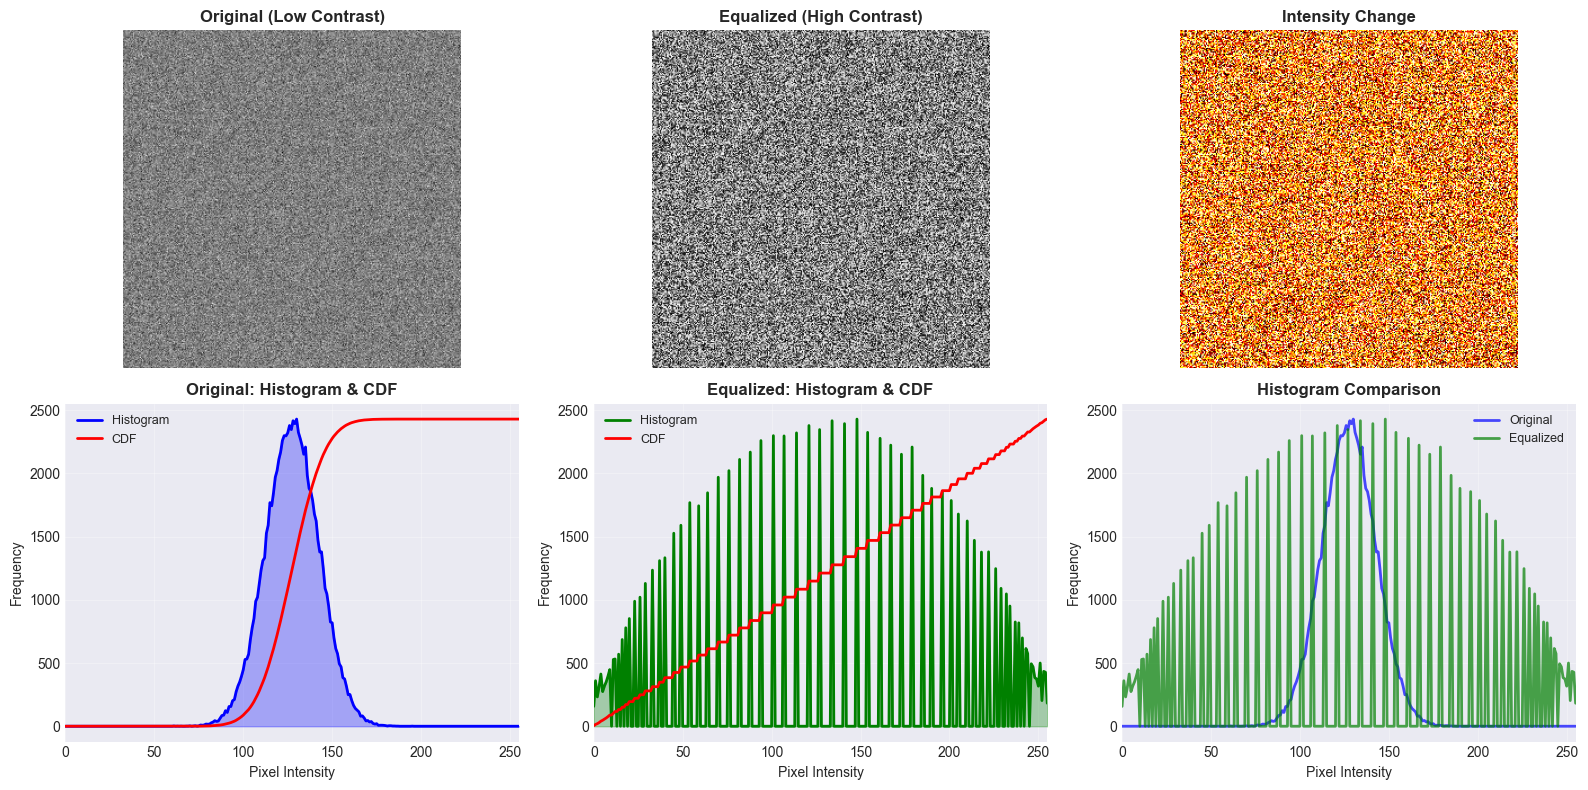

Histogram Equalization Results:
Original image - Contrast: 15.02
Equalized image - Contrast: 73.61
Improvement: 390.0%


In [22]:
# Create a low-contrast image
np.random.seed(42)
low_contrast = np.random.normal(128, 15, (300, 300)).astype(np.uint8)

# Apply histogram equalization
equalized = cv2.equalizeHist(low_contrast)

# Calculate histograms
hist_orig = cv2.calcHist([low_contrast], [0], None, [256], [0, 256])
hist_eq = cv2.calcHist([equalized], [0], None, [256], [0, 256])

# Calculate CDFs
cdf_orig = np.cumsum(hist_orig)
cdf_orig_normalized = cdf_orig * hist_orig.max() / cdf_orig.max()

cdf_eq = np.cumsum(hist_eq)
cdf_eq_normalized = cdf_eq * hist_eq.max() / cdf_eq.max()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Original image
ax = axes[0, 0]
ax.imshow(low_contrast, cmap='gray')
ax.set_title('Original (Low Contrast)', fontsize=12, fontweight='bold')
ax.axis('off')

# Equalized image
ax = axes[0, 1]
ax.imshow(equalized, cmap='gray')
ax.set_title('Equalized (High Contrast)', fontsize=12, fontweight='bold')
ax.axis('off')

# Difference
ax = axes[0, 2]
diff = cv2.absdiff(low_contrast.astype(float), equalized.astype(float))
ax.imshow(diff, cmap='hot')
ax.set_title('Intensity Change', fontsize=12, fontweight='bold')
ax.axis('off')

# Original histogram
ax = axes[1, 0]
ax.plot(hist_orig, color='blue', linewidth=2, label='Histogram')
ax.plot(cdf_orig_normalized, color='red', linewidth=2, label='CDF')
ax.fill_between(range(256), hist_orig.flatten(), alpha=0.3, color='blue')
ax.set_title('Original: Histogram & CDF', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 255)

# Equalized histogram
ax = axes[1, 1]
ax.plot(hist_eq, color='green', linewidth=2, label='Histogram')
ax.plot(cdf_eq_normalized, color='red', linewidth=2, label='CDF')
ax.fill_between(range(256), hist_eq.flatten(), alpha=0.3, color='green')
ax.set_title('Equalized: Histogram & CDF', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 255)

# Comparison
ax = axes[1, 2]
ax.plot(hist_orig, color='blue', linewidth=2, label='Original', alpha=0.7)
ax.plot(hist_eq, color='green', linewidth=2, label='Equalized', alpha=0.7)
ax.set_title('Histogram Comparison', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()

print("Histogram Equalization Results:")
print(f"Original image - Contrast: {np.std(low_contrast):.2f}")
print(f"Equalized image - Contrast: {np.std(equalized):.2f}")
print(f"Improvement: {(np.std(equalized) / np.std(low_contrast) - 1) * 100:.1f}%")

## 8. CLAHE (Contrast Limited Adaptive Histogram Equalization)

### Why CLAHE?
- Standard histogram equalization works globally → can create artifacts
- CLAHE works locally on small regions → better detail preservation
- Contrast limiting prevents noise amplification

### Process
1. Divide image into small tiles (8×8 typically)
2. Compute histogram for each tile
3. Limit histogram values to prevent noise (clip limit)
4. Apply histogram equalization to each tile
5. Interpolate boundaries between tiles for smooth transitions

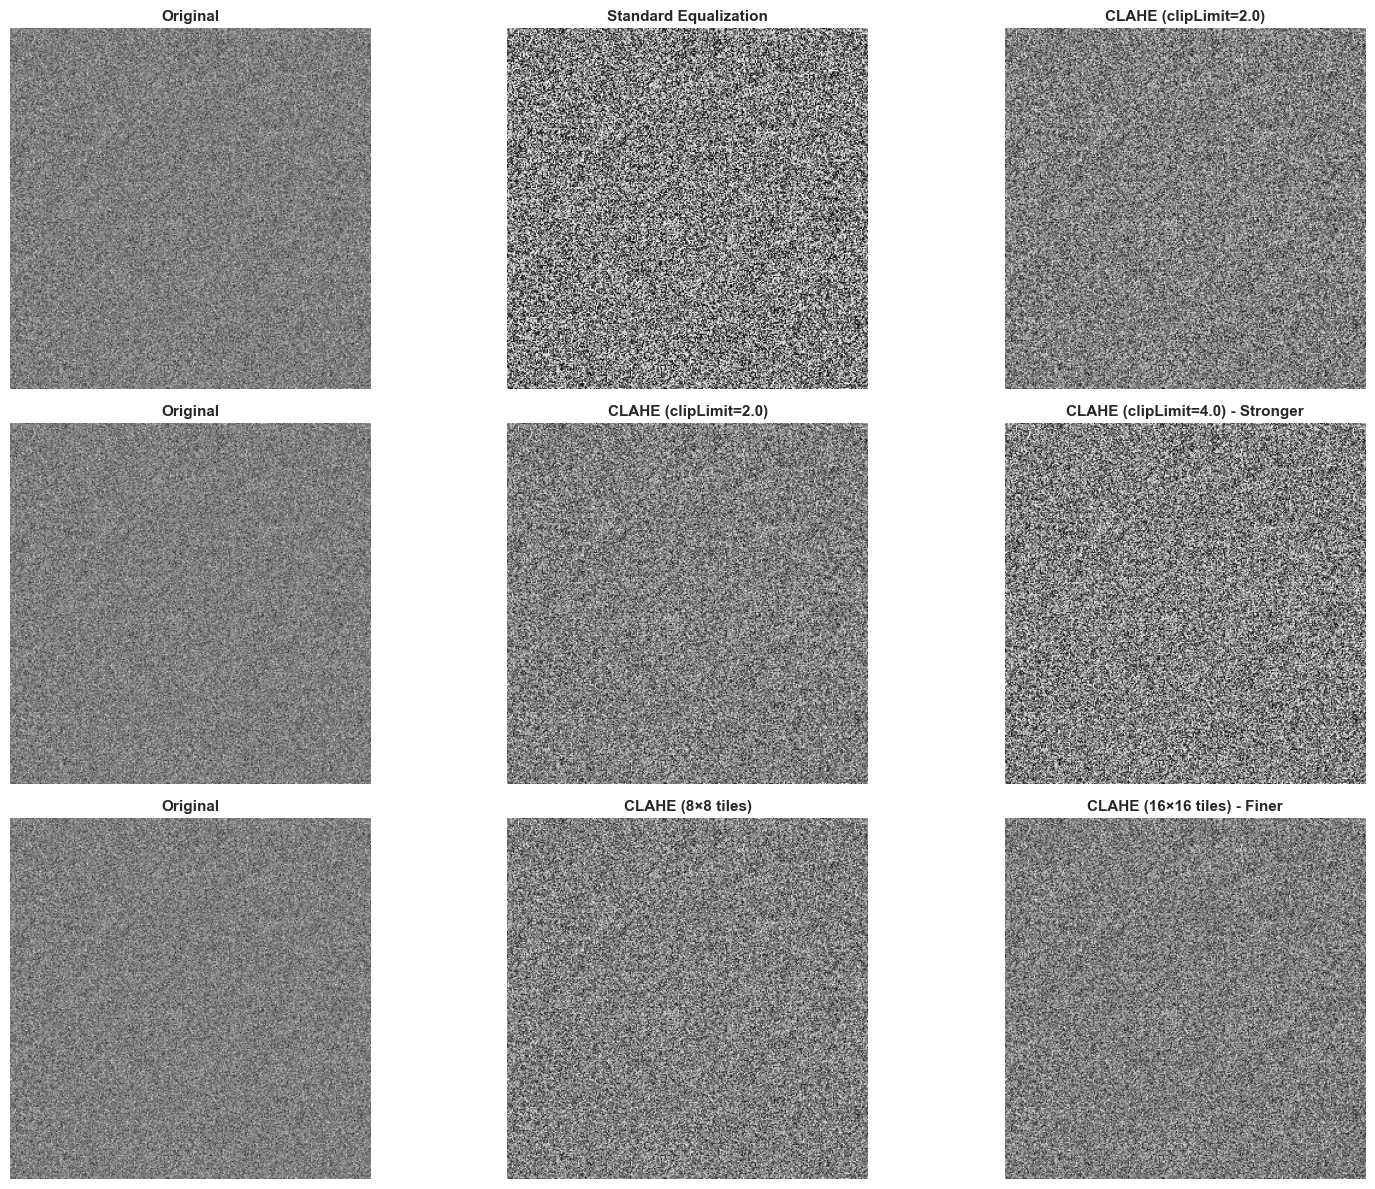

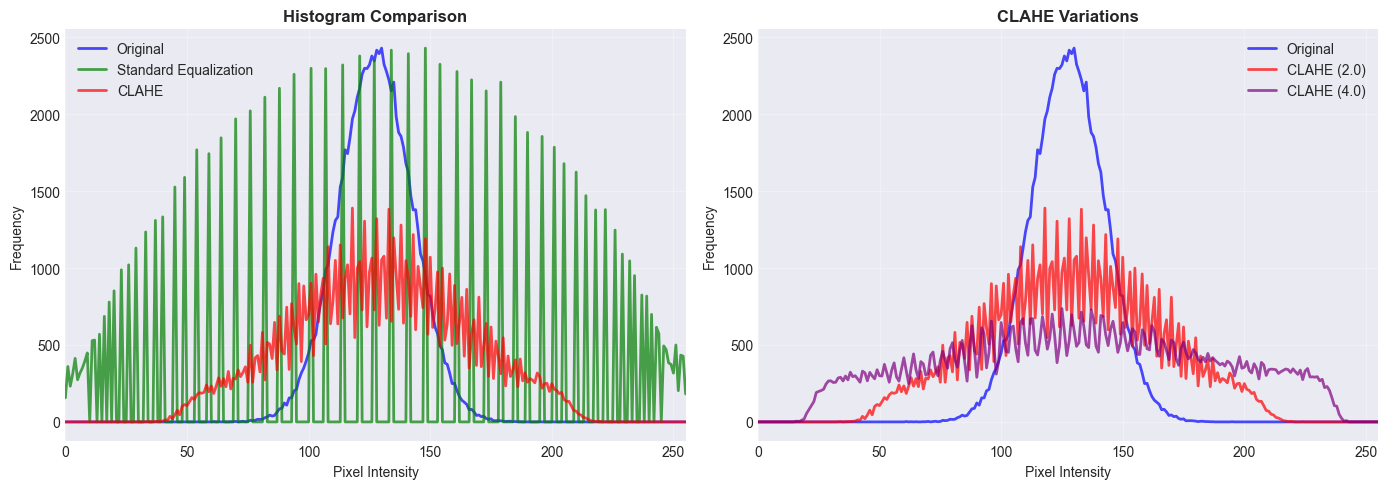


CLAHE Results:
Original contrast: 15.02
Standard Equalization contrast: 73.61
CLAHE contrast: 35.59

CLAHE preserves details better while still improving contrast!


In [23]:
# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_result = clahe.apply(low_contrast)

# Also create variants with different parameters
clahe_strong = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
clahe_strong_result = clahe_strong.apply(low_contrast)

clahe_fine = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
clahe_fine_result = clahe_fine.apply(low_contrast)

# Calculate histograms
hist_clahe = cv2.calcHist([clahe_result], [0], None, [256], [0, 256])
hist_clahe_strong = cv2.calcHist([clahe_strong_result], [0], None, [256], [0, 256])

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# Row 1: Standard Equalization vs CLAHE
ax = axes[0, 0]
ax.imshow(low_contrast, cmap='gray')
ax.set_title('Original', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[0, 1]
ax.imshow(equalized, cmap='gray')
ax.set_title('Standard Equalization', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[0, 2]
ax.imshow(clahe_result, cmap='gray')
ax.set_title('CLAHE (clipLimit=2.0)', fontsize=11, fontweight='bold')
ax.axis('off')

# Row 2: CLAHE Variations
ax = axes[1, 0]
ax.imshow(low_contrast, cmap='gray')
ax.set_title('Original', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[1, 1]
ax.imshow(clahe_result, cmap='gray')
ax.set_title('CLAHE (clipLimit=2.0)', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[1, 2]
ax.imshow(clahe_strong_result, cmap='gray')
ax.set_title('CLAHE (clipLimit=4.0) - Stronger', fontsize=11, fontweight='bold')
ax.axis('off')

# Row 3: Tile Size Effect
ax = axes[2, 0]
ax.imshow(low_contrast, cmap='gray')
ax.set_title('Original', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[2, 1]
ax.imshow(clahe_result, cmap='gray')
ax.set_title('CLAHE (8×8 tiles)', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[2, 2]
ax.imshow(clahe_fine_result, cmap='gray')
ax.set_title('CLAHE (16×16 tiles) - Finer', fontsize=11, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(hist_orig, color='blue', linewidth=2, label='Original', alpha=0.7)
ax.plot(hist_eq, color='green', linewidth=2, label='Standard Equalization', alpha=0.7)
ax.plot(hist_clahe, color='red', linewidth=2, label='CLAHE', alpha=0.7)
ax.set_title('Histogram Comparison', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 255)

ax = axes[1]
ax.plot(hist_orig, color='blue', linewidth=2, label='Original', alpha=0.7)
ax.plot(hist_clahe, color='red', linewidth=2, label='CLAHE (2.0)', alpha=0.7)
ax.plot(hist_clahe_strong, color='purple', linewidth=2, label='CLAHE (4.0)', alpha=0.7)
ax.set_title('CLAHE Variations', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()

print("\nCLAHE Results:")
print(f"Original contrast: {np.std(low_contrast):.2f}")
print(f"Standard Equalization contrast: {np.std(equalized):.2f}")
print(f"CLAHE contrast: {np.std(clahe_result):.2f}")
print("\nCLAHE preserves details better while still improving contrast!")

## 9. Otsu's Thresholding

### Purpose
Automatically determine the optimal threshold value to separate foreground from background.

### Key Idea
Find threshold that **maximizes the between-class variance** of the two resulting classes.

### Algorithm
1. Calculate histogram of image
2. For each possible threshold t:
   - Calculate foreground (0 to t) and background (t+1 to 255) statistics
   - Compute between-class variance
3. Select threshold with maximum variance
4. Segment: pixels < t = background, pixels ≥ t = foreground

### Mathematical Formula
$$\sigma_B^2(t) = \omega_0(t) \cdot \omega_1(t) \cdot [\mu_0(t) - \mu_1(t)]^2$$

Where:
- ω₀, ω₁: class probabilities
- μ₀, μ₁: class means

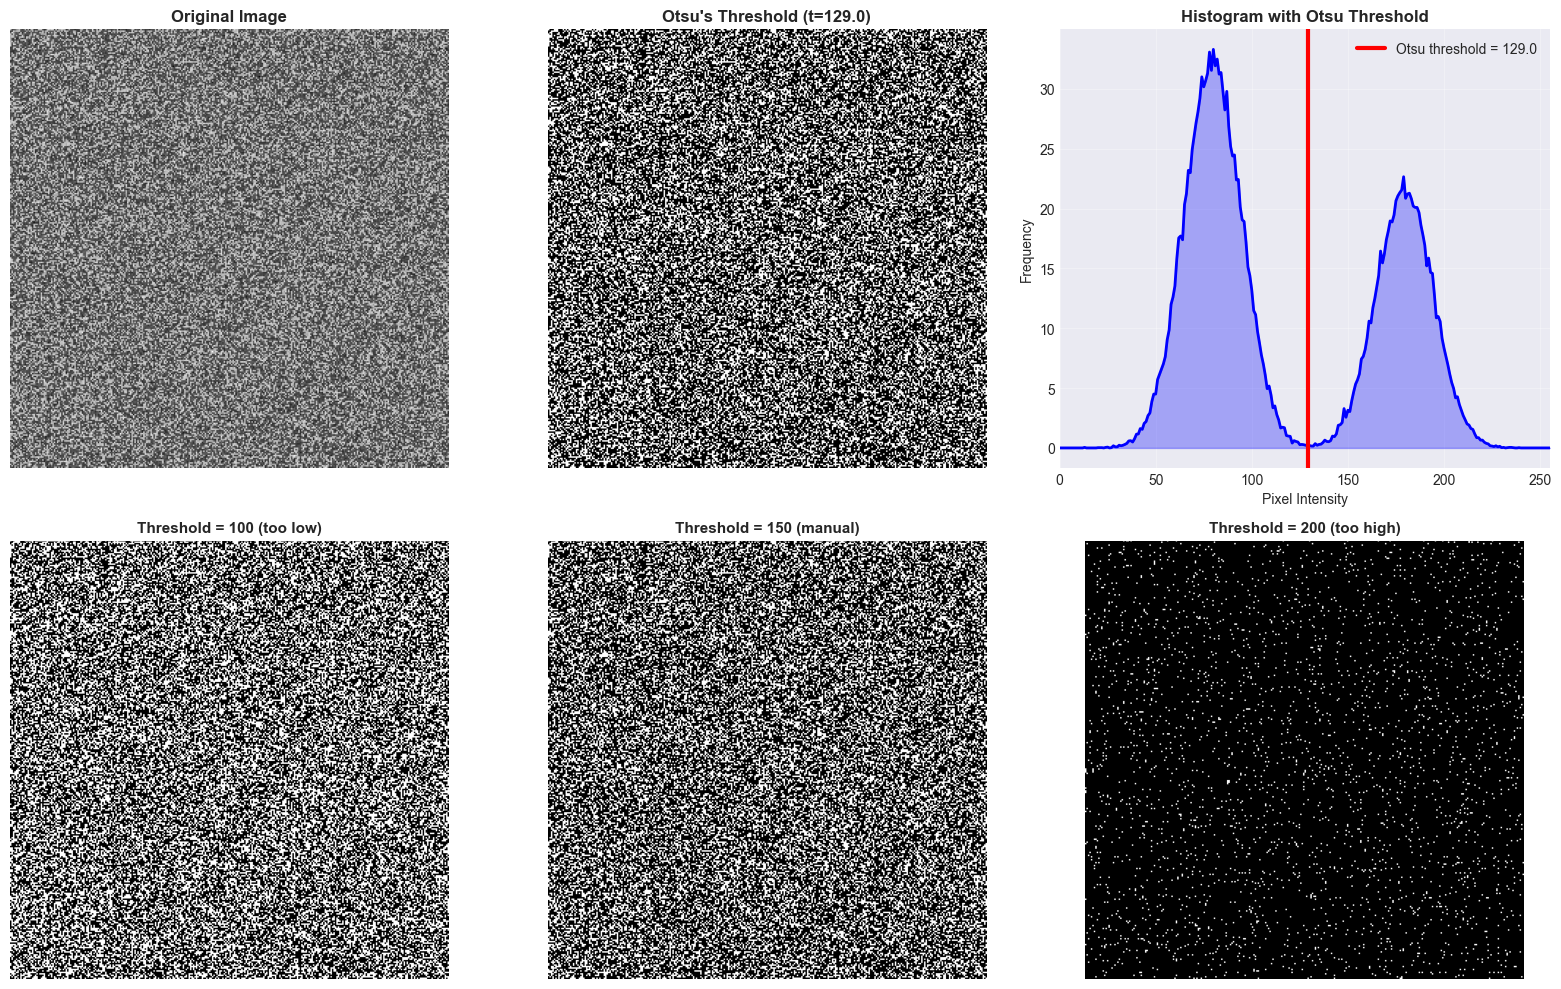

Otsu's Optimal Threshold: 129.0

Comparison with manual thresholds:
  t=100: Likely over-segments (too much foreground)
  t=129.0: Optimal (maximizes between-class variance)
  t=200: Likely under-segments (too little foreground)


In [24]:
# Create a bimodal image (good for thresholding)
np.random.seed(42)
background = np.random.normal(80, 15, (300, 300))
foreground = np.random.normal(180, 15, (300, 300))
mask = np.random.rand(300, 300) > 0.6

bimodal_image = np.where(mask, foreground, background).astype(np.uint8)

# Apply Otsu's thresholding
otsu_threshold, otsu_binary = cv2.threshold(bimodal_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Also try manual thresholds for comparison
_, binary_100 = cv2.threshold(bimodal_image, 100, 255, cv2.THRESH_BINARY)
_, binary_150 = cv2.threshold(bimodal_image, 150, 255, cv2.THRESH_BINARY)
_, binary_200 = cv2.threshold(bimodal_image, 200, 255, cv2.THRESH_BINARY)

# Calculate histogram and show where Otsu found the threshold
hist = cv2.calcHist([bimodal_image], [0], None, [256], [0, 256])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Visualization
ax = axes[0, 0]
ax.imshow(bimodal_image, cmap='gray')
ax.set_title('Original Image', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[0, 1]
ax.imshow(otsu_binary, cmap='gray')
ax.set_title(f"Otsu's Threshold (t={otsu_threshold})", fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[0, 2]
# Overlay threshold line on image
img_with_threshold = bimodal_image.copy()
hist_normalized = cv2.normalize(hist, hist).flatten() * 200  # Scale for visualization
ax.plot(hist_normalized, color='blue', linewidth=2)
ax.fill_between(range(256), hist_normalized, alpha=0.3, color='blue')
ax.axvline(otsu_threshold, color='red', linewidth=3, label=f'Otsu threshold = {otsu_threshold}')
ax.set_title('Histogram with Otsu Threshold', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 255)

# Row 2: Comparison of different thresholds
thresholds_demo = [
    (binary_100, '100 (too low)'),
    (binary_150, '150 (manual)'),
    (binary_200, '200 (too high)')
]

for idx, (binary_img, title) in enumerate(thresholds_demo):
    ax = axes[1, idx]
    ax.imshow(binary_img, cmap='gray')
    ax.set_title(f'Threshold = {title}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Otsu's Optimal Threshold: {otsu_threshold}")
print(f"\nComparison with manual thresholds:")
print(f"  t=100: Likely over-segments (too much foreground)")
print(f"  t={otsu_threshold}: Optimal (maximizes between-class variance)")
print(f"  t=200: Likely under-segments (too little foreground)")

### Otsu's Method in Detail

Manual Otsu calculation: 0
OpenCV Otsu result: 129.0
Match: False


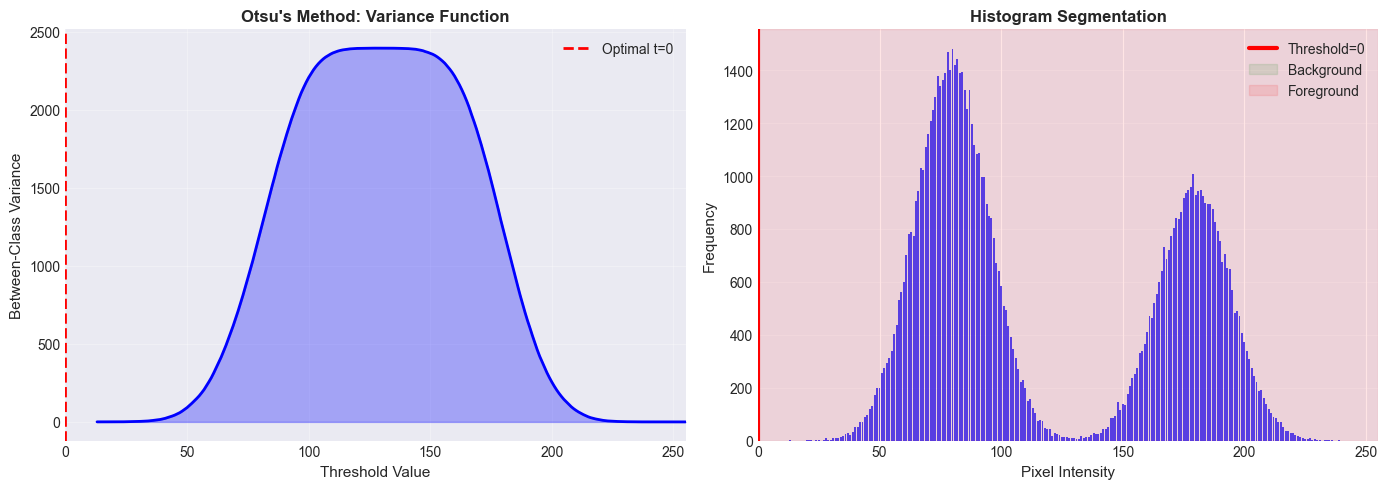

In [25]:
# Implement Otsu's thresholding manually to understand the process
def otsu_threshold_manual(image):
    """
    Manually implement Otsu's thresholding
    """
    # Calculate histogram
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()
    hist_norm = hist / hist.sum()  # Normalize to probabilities
    
    # Total number of pixels
    N = image.size
    
    # Calculate cumulative sums and means
    weight1 = np.cumsum(hist_norm)
    weight2 = 1 - weight1
    mean1 = np.cumsum(hist_norm * np.arange(256)) / weight1
    mean2 = (np.sum(hist_norm * np.arange(256)) - np.cumsum(hist_norm * np.arange(256))) / weight2
    
    # Avoid division by zero
    mean2[weight2 == 0] = 0
    
    # Between-class variance
    variance_between = weight1 * weight2 * (mean1 - mean2) ** 2
    
    # Find maximum variance
    threshold = np.argmax(variance_between)
    max_variance = np.max(variance_between)
    
    return threshold, variance_between

# Calculate manual Otsu
manual_threshold, variance_between = otsu_threshold_manual(bimodal_image)

print(f"Manual Otsu calculation: {manual_threshold}")
print(f"OpenCV Otsu result: {otsu_threshold}")
print(f"Match: {manual_threshold == otsu_threshold}")

# Visualize the variance function
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance curve
ax = axes[0]
ax.plot(variance_between, linewidth=2, color='blue')
ax.axvline(manual_threshold, color='red', linewidth=2, linestyle='--', label=f'Optimal t={manual_threshold}')
ax.fill_between(range(256), variance_between, alpha=0.3, color='blue')
ax.set_xlabel('Threshold Value', fontsize=11)
ax.set_ylabel('Between-Class Variance', fontsize=11)
ax.set_title("Otsu's Method: Variance Function", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 255)

# Histogram with threshold
ax = axes[1]
hist = cv2.calcHist([bimodal_image], [0], None, [256], [0, 256])
ax.bar(range(256), hist.flatten(), color='blue', alpha=0.7)
ax.axvline(manual_threshold, color='red', linewidth=3, label=f'Threshold={manual_threshold}')
ax.axvspan(0, manual_threshold, alpha=0.1, color='green', label='Background')
ax.axvspan(manual_threshold, 255, alpha=0.1, color='red', label='Foreground')
ax.set_xlabel('Pixel Intensity', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Histogram Segmentation', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()

---
# PART 3: FINAL DELIVERABLE - HISTOGRAM EQUALIZATION + OTSU THRESHOLDING DEMO
---

## 10. Complete Demo: Real-World Application

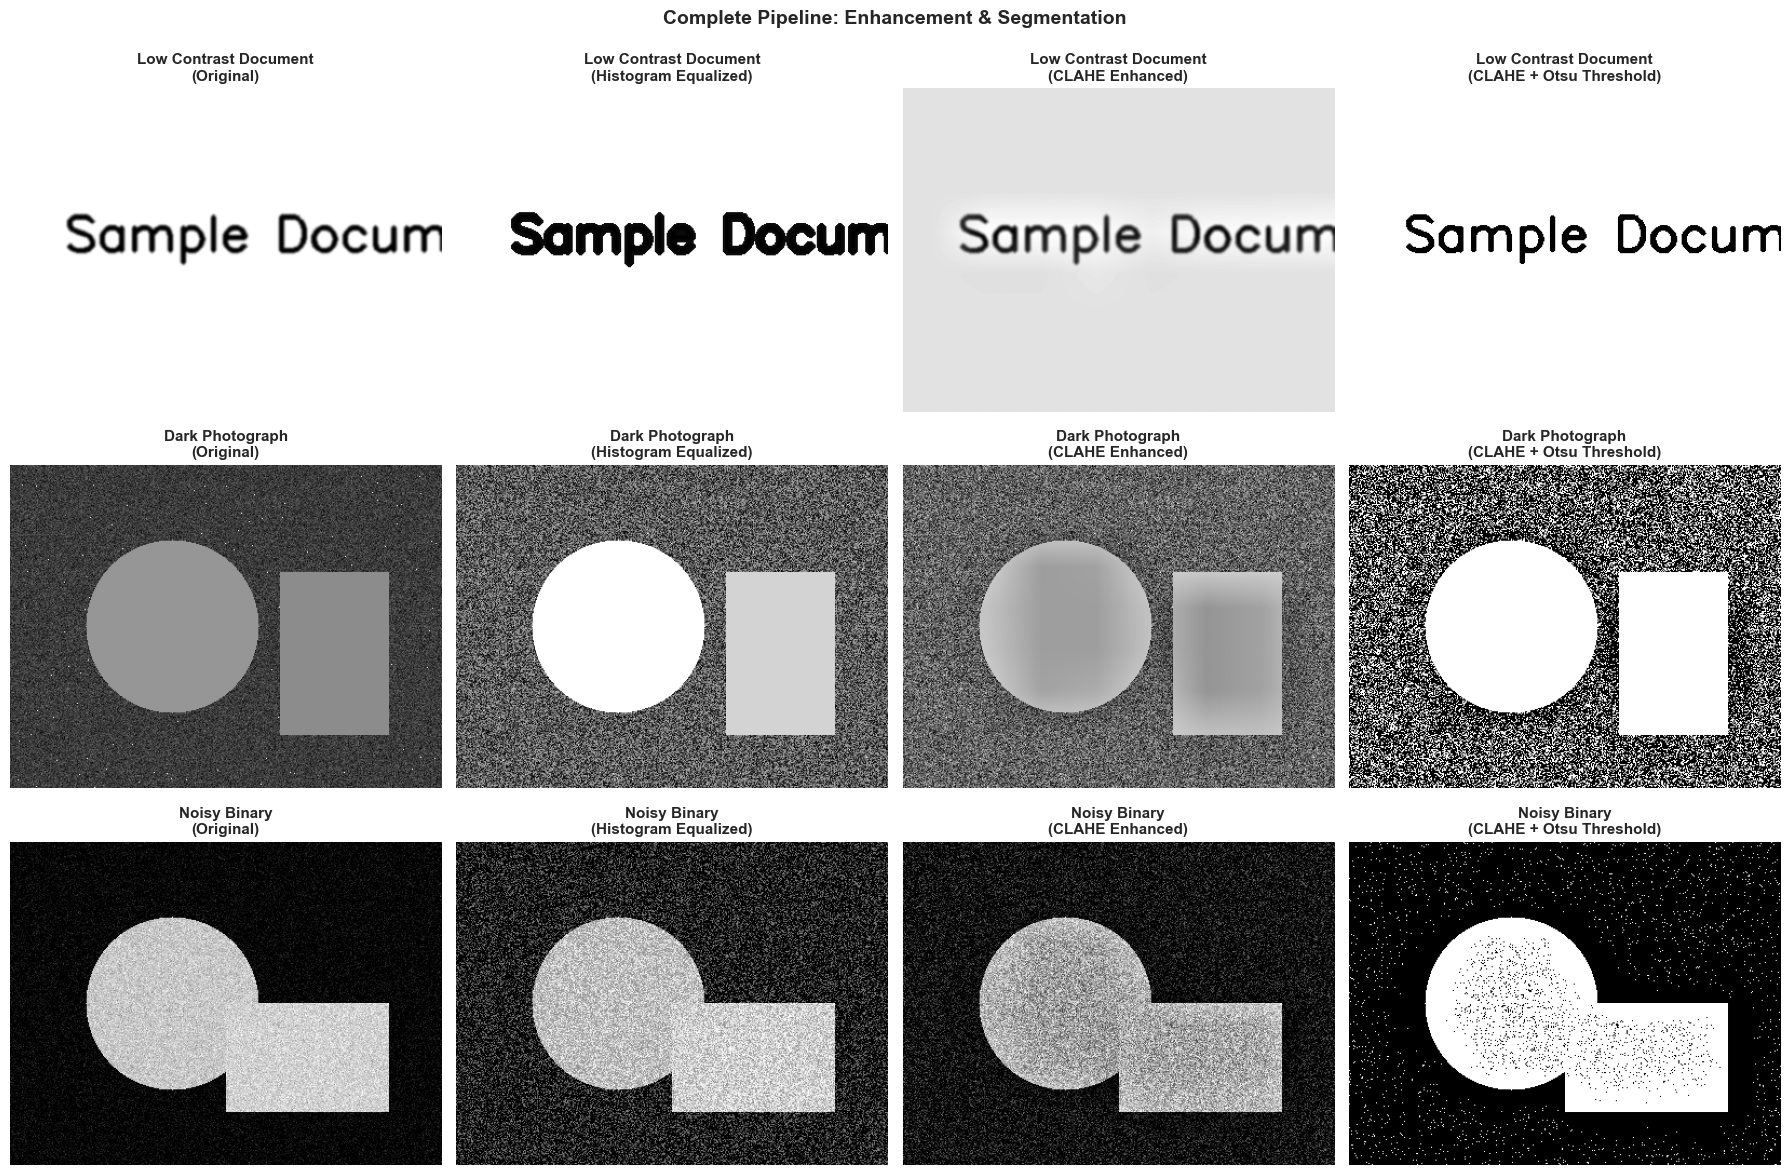

✓ Complete pipeline applied successfully!


In [26]:
# Create realistic test images with various challenges
np.random.seed(42)

# Image 1: Low contrast document
document = np.ones((300, 400, 3), dtype=np.uint8) * 200
cv2.putText(document, 'Sample Document', (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (120, 120, 120), 3)
document_gray = cv2.cvtColor(document, cv2.COLOR_BGR2GRAY)
document_gray = cv2.GaussianBlur(document_gray, (5, 5), 0)  # Add blur

# Image 2: Dark photo
dark_image = np.random.normal(60, 20, (300, 400)).astype(np.uint8)
cv2.circle(dark_image, (150, 150), 80, 150, -1)
cv2.rectangle(dark_image, (250, 100), (350, 250), 140, -1)

# Image 3: Binary-like with noise
binary_noisy = np.zeros((300, 400), dtype=np.uint8)
cv2.circle(binary_noisy, (150, 150), 80, 200, -1)
cv2.rectangle(binary_noisy, (200, 150), (350, 250), 210, -1)
# Add Gaussian noise
noise = np.random.normal(0, 20, binary_noisy.shape)
binary_noisy = np.clip(binary_noisy.astype(float) + noise, 0, 255).astype(np.uint8)

test_images = [
    (document_gray, "Low Contrast Document"),
    (dark_image, "Dark Photograph"),
    (binary_noisy, "Noisy Binary")
]

# Process each image
fig, axes = plt.subplots(len(test_images), 4, figsize=(18, 12))

for row, (image, title) in enumerate(test_images):
    # Original
    ax = axes[row, 0]
    ax.imshow(image, cmap='gray')
    ax.set_title(f'{title}\n(Original)', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # Histogram Equalization
    equalized = cv2.equalizeHist(image)
    ax = axes[row, 1]
    ax.imshow(equalized, cmap='gray')
    ax.set_title(f'{title}\n(Histogram Equalized)', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_result = clahe.apply(image)
    ax = axes[row, 2]
    ax.imshow(clahe_result, cmap='gray')
    ax.set_title(f'{title}\n(CLAHE Enhanced)', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # Otsu's Thresholding on CLAHE result
    _, otsu_binary = cv2.threshold(clahe_result, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    ax = axes[row, 3]
    ax.imshow(otsu_binary, cmap='gray')
    ax.set_title(f'{title}\n(CLAHE + Otsu Threshold)', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Complete Pipeline: Enhancement & Segmentation', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Complete pipeline applied successfully!")

## 11. Advanced: Multi-Level Thresholding (Niblack & Sauvola)

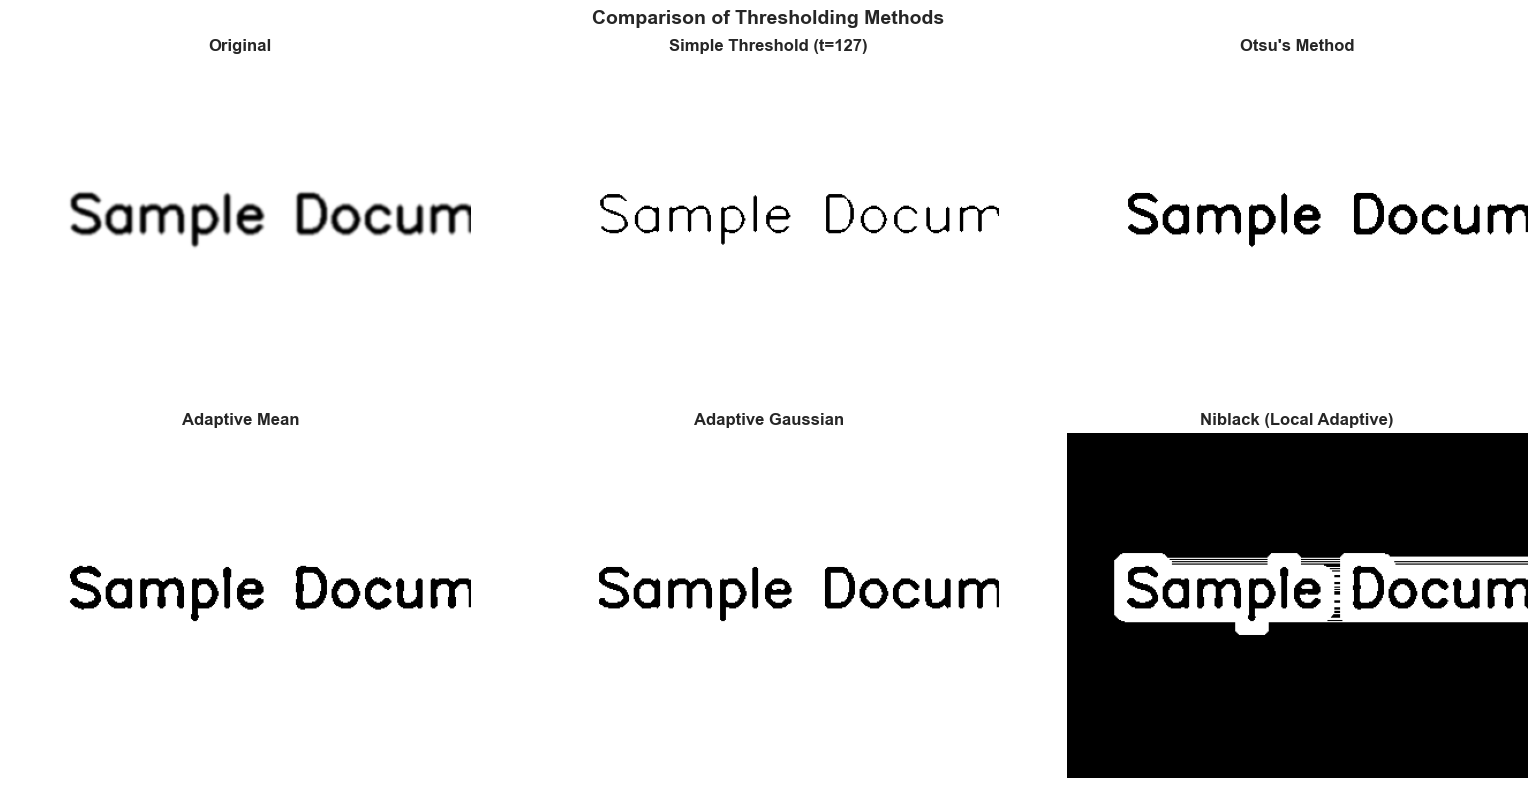

Thresholding Methods Comparison:

1. Simple Threshold (t=127): Fast but not adaptive
2. Otsu's Method: Optimal global threshold for bimodal distributions
3. Adaptive Mean: Uses local mean, good for varying lighting
4. Adaptive Gaussian: Weighted local adaptation
5. Niblack: Uses local mean and standard deviation


In [27]:
from scipy.ndimage import uniform_filter, uniform_filter1d

# Implement Niblack thresholding
def niblack_threshold(image, window_size=15, k=0.2):
    """
    Niblack thresholding - adaptive method
    
    Parameters:
    -----------
    window_size : int
        Size of local window
    k : float
        Weighting factor (typically 0.2)
    """
    h, w = image.shape
    
    # Compute local mean
    local_mean = uniform_filter(image.astype(float), size=window_size)
    
    # Compute local standard deviation
    local_sqr_mean = uniform_filter(image.astype(float)**2, size=window_size)
    local_std = np.sqrt(np.maximum(local_sqr_mean - local_mean**2, 0))
    
    # Threshold
    threshold_map = local_mean - k * local_std
    binary = (image.astype(float) > threshold_map).astype(np.uint8) * 255
    
    return binary, threshold_map

# Apply Niblack
niblack_result, threshold_map = niblack_threshold(document_gray, window_size=21, k=0.2)

# Compare different thresholding methods
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Row 1: Global methods
ax = axes[0, 0]
ax.imshow(document_gray, cmap='gray')
ax.set_title('Original', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[0, 1]
_, simple_threshold = cv2.threshold(document_gray, 127, 255, cv2.THRESH_BINARY)
ax.imshow(simple_threshold, cmap='gray')
ax.set_title('Simple Threshold (t=127)', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[0, 2]
_, otsu_result = cv2.threshold(document_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
ax.imshow(otsu_result, cmap='gray')
ax.set_title("Otsu's Method", fontsize=12, fontweight='bold')
ax.axis('off')

# Row 2: Adaptive methods
ax = axes[1, 0]
adaptive_result = cv2.adaptiveThreshold(document_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                        cv2.THRESH_BINARY, 21, 5)
ax.imshow(adaptive_result, cmap='gray')
ax.set_title('Adaptive Mean', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[1, 1]
adaptive_gaussian = cv2.adaptiveThreshold(document_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 21, 5)
ax.imshow(adaptive_gaussian, cmap='gray')
ax.set_title('Adaptive Gaussian', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[1, 2]
ax.imshow(niblack_result, cmap='gray')
ax.set_title('Niblack (Local Adaptive)', fontsize=12, fontweight='bold')
ax.axis('off')

plt.suptitle('Comparison of Thresholding Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Thresholding Methods Comparison:")
print("\n1. Simple Threshold (t=127): Fast but not adaptive")
print("2. Otsu's Method: Optimal global threshold for bimodal distributions")
print("3. Adaptive Mean: Uses local mean, good for varying lighting")
print("4. Adaptive Gaussian: Weighted local adaptation")
print("5. Niblack: Uses local mean and standard deviation")

## 12. Complete Workflow: Image Processing Pipeline

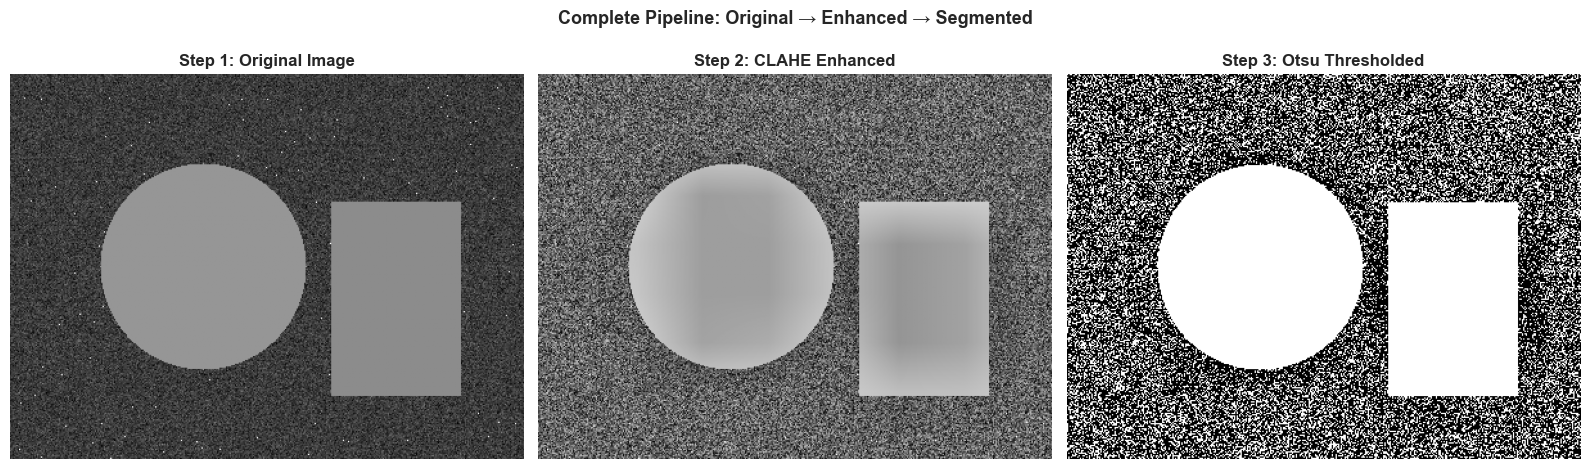

✓ Complete pipeline executed successfully!

Pipeline steps:
1. Read image (grayscale)
2. Apply CLAHE for local contrast enhancement
3. Apply Otsu's thresholding for automatic segmentation
4. Result: Binary image suitable for object detection/counting


In [28]:
# Complete pipeline function
def image_enhancement_pipeline(image_path_or_array, method='clahe_otsu'):
    """
    Complete image enhancement and segmentation pipeline
    
    Parameters:
    -----------
    image_path_or_array : str or ndarray
        Input image path or array
    method : str
        'simple': Simple thresholding
        'otsu': Otsu thresholding
        'clahe': CLAHE enhancement
        'clahe_otsu': CLAHE + Otsu (recommended)
        'adaptive': Adaptive thresholding
    """
    # Load image if path provided
    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array, cv2.IMREAD_GRAYSCALE)
    else:
        img = image_path_or_array.copy()
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    results = {'original': img}
    
    if method in ['clahe_otsu', 'clahe']:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        results['enhanced'] = clahe.apply(img)
    else:
        results['enhanced'] = cv2.equalizeHist(img)
    
    if method == 'simple':
        _, results['binary'] = cv2.threshold(results['enhanced'], 127, 255, cv2.THRESH_BINARY)
    elif method == 'otsu':
        _, results['binary'] = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif method == 'clahe_otsu':
        _, results['binary'] = cv2.threshold(results['enhanced'], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif method == 'adaptive':
        results['binary'] = cv2.adaptiveThreshold(results['enhanced'], 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                                  cv2.THRESH_BINARY, 21, 5)
    
    return results

# Test the complete pipeline
results = image_enhancement_pipeline(dark_image, method='clahe_otsu')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.imshow(results['original'], cmap='gray')
ax.set_title('Step 1: Original Image', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[1]
ax.imshow(results['enhanced'], cmap='gray')
ax.set_title('Step 2: CLAHE Enhanced', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[2]
ax.imshow(results['binary'], cmap='gray')
ax.set_title('Step 3: Otsu Thresholded', fontsize=12, fontweight='bold')
ax.axis('off')

plt.suptitle('Complete Pipeline: Original → Enhanced → Segmented', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Complete pipeline executed successfully!")
print("\nPipeline steps:")
print("1. Read image (grayscale)")
print("2. Apply CLAHE for local contrast enhancement")
print("3. Apply Otsu's thresholding for automatic segmentation")
print("4. Result: Binary image suitable for object detection/counting")

---
# SUMMARY & KEY TAKEAWAYS
---

## 13. Summary

In [29]:
summary = """
PROBABILITY & STATISTICS FOR COMPUTER VISION - COMPLETE SUMMARY
================================================================

MORNING (AM) TOPICS:
───────────────────

1. PROBABILITY FUNDAMENTALS
   ✓ Basic probability concepts (0 to 1 range)
   ✓ Probability Density Function (PDF)
   ✓ Cumulative Distribution Function (CDF)

2. GAUSSIAN (NORMAL) DISTRIBUTION
   ✓ Most important in statistics and CV
   ✓ Parameterized by mean (μ) and standard deviation (σ)
   ✓ 68-95-99.7 rule: coverage at different σ levels
   ✓ Bell-shaped, symmetric around mean
   ✓ Ubiquitous in natural phenomena

3. BIVARIATE GAUSSIAN (2D)
   ✓ Extension to multiple dimensions
   ✓ Covariance matrix describes correlations
   ✓ Multivariate normal for feature distributions

4. BAYES' THEOREM
   ✓ Mathematical: P(A|B) = P(B|A) × P(A) / P(B)
   ✓ Posterior = Likelihood × Prior / Evidence
   ✓ Foundation of probabilistic machine learning
   ✓ Prior probability significantly affects posterior

5. IMAGE HISTOGRAMS & STATISTICS
   ✓ Distribution of pixel intensities
   ✓ Grayscale and color histograms
   ✓ Statistical measures: mean, variance, skewness, kurtosis, entropy
   ✓ Histogram shape indicates image characteristics


AFTERNOON (PM) TOPICS:
──────────────────────

1. HISTOGRAM EQUALIZATION
   ✓ Redistributes pixel intensities uniformly
   ✓ Improves contrast globally
   ✓ Process: PDF → CDF → Mapping
   ✓ Benefits: Enhanced visibility, uniform histogram
   ✓ Drawbacks: Can amplify noise, unnatural appearance

2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
   ✓ Local histogram equalization (8×8 tiles typical)
   ✓ Contrast limiting prevents noise amplification
   ✓ Better detail preservation than global equalization
   ✓ Hyperparameters: clipLimit and tileGridSize
   ✓ More natural-looking results

3. OTSU'S THRESHOLDING
   ✓ Automatic optimal threshold determination
   ✓ Maximizes between-class variance
   ✓ Formula: σ²ᵦ(t) = ω₀(t) × ω₁(t) × [μ₀(t) - μ₁(t)]²
   ✓ Works well for bimodal distributions
   ✓ No manual threshold selection needed

4. ADAPTIVE THRESHOLDING
   ✓ Local threshold for varying lighting conditions
   ✓ Mean-based and Gaussian-weighted variants
   ✓ Better for non-uniform illumination
   ✓ Niblack method: uses local mean and std dev


KEY MATHEMATICAL CONCEPTS:
──────────────────────────

• Probability distributions describe randomness
• Gaussian distribution: ubiquitous and well-understood
• Bayes' theorem: combining prior knowledge with evidence
• Histograms: summary statistic of image content
• Threshold selection: critical for segmentation
• Variance maximization: core principle of Otsu's method


PRACTICAL APPLICATIONS:
───────────────────────

1. Image Enhancement
   → Improve visibility and contrast
   → Prepare images for further processing
   → Handle varying lighting conditions

2. Image Segmentation
   → Separate foreground from background
   → Object detection and localization
   → Region-based analysis

3. Quality Assessment
   → Histogram analysis for image quality
   → Entropy-based focus detection
   → Exposure and contrast evaluation

4. Medical Imaging
   → Tissue segmentation
   → Lesion detection
   → Image registration

5. Document Processing
   → Text binarization
   → Document scanning enhancement
   → OCR preprocessing


RECOMMENDED WORKFLOW:
──────────────────────

1. Load image (grayscale if color image)
2. Apply CLAHE for adaptive contrast enhancement
3. Use Otsu's thresholding for automatic segmentation
4. Apply morphological operations if needed (erode, dilate)
5. Extract features or perform analysis

This pipeline handles most common CV preprocessing tasks!


WHEN TO USE EACH METHOD:
─────────────────────────

Histogram Equalization:
  → Simple, fast, global approach
  → When contrast improvement is main goal
  → When noise is not a concern

CLAHE:
  → Recommended for most practical applications
  → Good balance of contrast and noise control
  → Better detail preservation
  → Slightly more computational cost

Otsu Thresholding:
  → For bimodal or near-bimodal distributions
  → When automatic threshold selection is needed
  → Fast and requires no manual tuning
  → Works well on CLAHE-enhanced images

Adaptive Thresholding:
  → For varying illumination
  → Non-uniform lighting conditions
  → Better for local feature extraction
  → More computationally expensive


COMMON PITFALLS:
─────────────────

✗ Applying global thresholding to non-uniform images
✗ Over-enhancing with CLAHE (noise amplification)
✗ Using Otsu on non-bimodal distributions
✗ Ignoring preprocessing before analysis
✗ Assuming same parameters work for all images


BEST PRACTICES:
────────────────

✓ Always inspect histogram before processing
✓ Validate threshold selection visually
✓ Test multiple methods for your specific problem
✓ Consider noise levels when choosing enhancement
✓ Combine methods (CLAHE + Otsu works well)
✓ Keep preprocessing pipeline consistent
✓ Document parameter choices for reproducibility

"""

print(summary)


PROBABILITY & STATISTICS FOR COMPUTER VISION - COMPLETE SUMMARY

MORNING (AM) TOPICS:
───────────────────

1. PROBABILITY FUNDAMENTALS
   ✓ Basic probability concepts (0 to 1 range)
   ✓ Probability Density Function (PDF)
   ✓ Cumulative Distribution Function (CDF)

2. GAUSSIAN (NORMAL) DISTRIBUTION
   ✓ Most important in statistics and CV
   ✓ Parameterized by mean (μ) and standard deviation (σ)
   ✓ 68-95-99.7 rule: coverage at different σ levels
   ✓ Bell-shaped, symmetric around mean
   ✓ Ubiquitous in natural phenomena

3. BIVARIATE GAUSSIAN (2D)
   ✓ Extension to multiple dimensions
   ✓ Covariance matrix describes correlations
   ✓ Multivariate normal for feature distributions

4. BAYES' THEOREM
   ✓ Mathematical: P(A|B) = P(B|A) × P(A) / P(B)
   ✓ Posterior = Likelihood × Prior / Evidence
   ✓ Foundation of probabilistic machine learning
   ✓ Prior probability significantly affects posterior

5. IMAGE HISTOGRAMS & STATISTICS
   ✓ Distribution of pixel intensities
   ✓ Grayscal

## 14. Practice Exercises

In [30]:
exercises = """
PRACTICE EXERCISES
==================

EXERCISE 1: Distribution Analysis
──────────────────────────────────
a) Generate 10,000 samples from:
   - Normal distribution: μ=100, σ=20
   - Uniform distribution: [50, 150]
   - Exponential distribution: λ=0.01

b) Plot their PDFs
c) Calculate mean, variance, skewness for each
d) Estimate probability P(X > 120) for each


EXERCISE 2: Bayes' Theorem Practice
─────────────────────────────────────
Problem: A spam filter is 95% accurate.
- 10% of emails are spam (prior)
- Email is flagged as spam by filter
- What's probability it's actually spam?

Calculate using Bayes' theorem and visualize the result.


EXERCISE 3: Histogram Statistics
──────────────────────────────────
a) Create 3 different images (dark, bright, noisy)
b) Calculate histogram for each
c) Compute: mean, std dev, entropy, skewness
d) Compare and interpret the statistics


EXERCISE 4: Histogram Equalization Effects
────────────────────────────────────────────
a) Create a low-contrast image
b) Apply:
   - Simple histogram equalization
   - CLAHE with different clipLimits (1, 2, 4)
   - CLAHE with different tile sizes (4, 8, 16)
c) Compare histograms and visual results
d) Which parameter combination is best for your image?


EXERCISE 5: Otsu's Thresholding Analysis
──────────────────────────────────────────
a) Create a test image with known objects
b) Apply Otsu's thresholding
c) Plot the between-class variance function
d) Verify the threshold is at maximum variance
e) Compare with manual thresholds


EXERCISE 6: Thresholding Method Comparison
────────────────────────────────────────────
For a challenging image:
a) Try all methods:
   - Simple (t=127)
   - Otsu
   - Adaptive Mean
   - Adaptive Gaussian
   - Niblack

b) Compare results visually
c) Measure segmentation quality (if ground truth available)
d) Document which method works best and why


EXERCISE 7: Complete Pipeline
───────────────────────────────
a) Load or create a complex image
b) Build complete pipeline:
   - CLAHE enhancement
   - Otsu thresholding
   - Morphological operations (optional)
   - Feature extraction

c) Visualize each step
d) Compare with and without enhancement


EXERCISE 8: Adaptive Parameter Selection
──────────────────────────────────────────
a) Create multiple test images
b) For each image, automatically select best:
   - Enhancement method
   - Enhancement parameters
   - Thresholding method

c) Implement heuristic rules based on histogram properties
d) Validate on new images


EXERCISE 9: Edge Cases
────────────────────────
Handle special cases:
a) Very bright/dark images
b) Extremely noisy images
c) Binary images (already segmented)
d) Uniform images (no structure)
e) Images with text and photos mixed

For each: What method works? Why does it fail for others?


EXERCISE 10: Real-World Application
─────────────────────────────────────
Choose a real-world problem:
- Medical image analysis
- Document scanning
- Satellite imagery
- Quality control
- Others

Build complete solution using:
- Appropriate histogram analysis
- Enhancement technique
- Thresholding method
- Morphological operations

Document and justify all choices.
"""

print(exercises)


PRACTICE EXERCISES

EXERCISE 1: Distribution Analysis
──────────────────────────────────
a) Generate 10,000 samples from:
   - Normal distribution: μ=100, σ=20
   - Uniform distribution: [50, 150]
   - Exponential distribution: λ=0.01

b) Plot their PDFs
c) Calculate mean, variance, skewness for each
d) Estimate probability P(X > 120) for each


EXERCISE 2: Bayes' Theorem Practice
─────────────────────────────────────
Problem: A spam filter is 95% accurate.
- 10% of emails are spam (prior)
- Email is flagged as spam by filter
- What's probability it's actually spam?

Calculate using Bayes' theorem and visualize the result.


EXERCISE 3: Histogram Statistics
──────────────────────────────────
a) Create 3 different images (dark, bright, noisy)
b) Calculate histogram for each
c) Compute: mean, std dev, entropy, skewness
d) Compare and interpret the statistics


EXERCISE 4: Histogram Equalization Effects
────────────────────────────────────────────
a) Create a low-contrast image
b) Apply:

## 15. Resources & Further Learning

In [31]:
resources = """
RESOURCES & FURTHER LEARNING
=============================

KEY LIBRARIES:
───────────────

NumPy:
  - Array operations and statistics
  - np.histogram(), np.mean(), np.std()
  - Random number generation

OpenCV:
  - Image processing functions
  - cv2.calcHist(): Histogram calculation
  - cv2.equalizeHist(): Histogram equalization
  - cv2.createCLAHE(): CLAHE enhancement
  - cv2.threshold(): Global thresholding
  - cv2.adaptiveThreshold(): Adaptive thresholding

SciPy:
  - Statistical distributions
  - scipy.stats for probability distributions
  - scipy.ndimage for advanced processing

Matplotlib/Seaborn:
  - Visualization of histograms and distributions
  - Distribution plots

Sklearn:
  - Statistical modeling
  - Preprocessing and normalization


KEY CONCEPTS TO MASTER:
─────────────────────────

✓ Understanding distribution properties
✓ Histogram interpretation and analysis
✓ Image enhancement trade-offs
✓ Automatic parameter selection
✓ Thresholding for segmentation
✓ Multi-channel image processing
✓ Computational efficiency considerations
✓ Numerical stability in computations


ADVANCED TOPICS:
─────────────────

→ Mixture of Gaussians (GMM) for multi-modal distributions
→ Expectation-Maximization for clustering
→ Kernel Density Estimation (KDE)
→ Advanced morphological operations
→ Connected component analysis
→ Watershed segmentation
→ Markov Random Fields
→ Conditional Random Fields (CRF)
→ Graph cuts for segmentation
→ Deep learning for image segmentation


WHEN TO USE DIFFERENT APPROACHES:
─────────────────────────────────────

Simple Methods (Histograms, Otsu):
  - Quick prototyping
  - Well-defined problems
  - Limited computational resources
  - Real-time processing needs

Adaptive Methods (CLAHE, Adaptive Thresholding):
  - Varying lighting conditions
  - Non-uniform image properties
  - Better detail preservation
  - More robust solutions

Advanced Methods (ML/DL):
  - Complex/ambiguous segmentation
  - Large-scale processing
  - High accuracy requirements
  - When manual tuning is expensive


BENCHMARKING & EVALUATION:
──────────────────────────

For Thresholding Quality:
  - Use Otsu as baseline
  - Measure edge accuracy if ground truth exists
  - Visual inspection for artifacts
  - Consider computational cost

For Enhancement:
  - Before/after contrast metrics
  - Peak Signal-to-Noise Ratio (PSNR)
  - Structural Similarity Index (SSIM)
  - Entropy-based quality measures


COMMON MISTAKES & HOW TO AVOID:
────────────────────────────────

1. Using global methods on varying images
   → Solution: Use adaptive methods

2. Over-enhancing and amplifying noise
   → Solution: Use contrast limiting (CLAHE)

3. Assuming same parameters work everywhere
   → Solution: Validate on diverse test sets

4. Not inspecting intermediate results
   → Solution: Visualize each pipeline step

5. Ignoring computational complexity
   → Solution: Profile code on realistic images


RECOMMENDED WORKFLOW FOR NEW PROBLEM:
───────────────────────────────────────

1. Analyze histogram of sample images
2. Try simple methods first (Otsu, histogram eq.)
3. If not satisfactory, try CLAHE + Otsu
4. For difficult cases, use adaptive methods
5. Validate on diverse test set
6. Document parameter choices
7. Implement as production-ready code


DEBUGGING TIPS:
────────────────

• Plot histograms frequently
• Visualize all intermediate steps
• Compare multiple methods side-by-side
• Test edge cases (very dark, very bright, noisy)
• Use known good images as reference
• Profile computational performance
• Check for numerical issues (NaN, infinity)
• Validate on multiple image types

"""

print(resources)


RESOURCES & FURTHER LEARNING

KEY LIBRARIES:
───────────────

NumPy:
  - Array operations and statistics
  - np.histogram(), np.mean(), np.std()
  - Random number generation

OpenCV:
  - Image processing functions
  - cv2.calcHist(): Histogram calculation
  - cv2.equalizeHist(): Histogram equalization
  - cv2.createCLAHE(): CLAHE enhancement
  - cv2.threshold(): Global thresholding
  - cv2.adaptiveThreshold(): Adaptive thresholding

SciPy:
  - Statistical distributions
  - scipy.stats for probability distributions
  - scipy.ndimage for advanced processing

Matplotlib/Seaborn:
  - Visualization of histograms and distributions
  - Distribution plots

Sklearn:
  - Statistical modeling
  - Preprocessing and normalization


KEY CONCEPTS TO MASTER:
─────────────────────────

✓ Understanding distribution properties
✓ Histogram interpretation and analysis
✓ Image enhancement trade-offs
✓ Automatic parameter selection
✓ Thresholding for segmentation
✓ Multi-channel image processing
✓ Computati

## 16. Conclusion

In [1]:
print("\n" + "*"*70)
print("*" + " "*68 + "*")
print("*" + "CONCLUSION: Probability & Statistics for Computer Vision".center(68) + "*")
print("*" + " "*68 + "*")
print("*"*70)
print()

conclusion = """
Throughout this comprehensive course, we've explored how probability
and statistics form the foundation of image processing:

1. PROBABILITY THEORY provides the mathematical framework
   - Understanding distributions of data
   - Quantifying uncertainty and randomness
   - Making informed decisions from data

2. GAUSSIAN DISTRIBUTION appears everywhere
   - Models natural noise in images
   - Foundation for many algorithms
   - Enables powerful probabilistic methods

3. BAYES' THEOREM enables learning from evidence
   - Combining prior knowledge with observations
   - Probabilistic reasoning and inference
   - Machine learning classification

4. HISTOGRAMS reveal image properties
   - Simple yet powerful analysis tool
   - Guide enhancement and segmentation
   - Enable statistical processing

5. ENHANCEMENT improves image quality
   - Histogram equalization: global approach
   - CLAHE: local adaptive enhancement
   - Trade-offs between methods

6. THRESHOLDING creates segmentation
   - Otsu's method: optimal global threshold
   - Adaptive methods: handle varying conditions
   - Critical step in many CV pipelines


KEY INSIGHTS:
──────────────

✓ Statistics guide all image processing decisions
✓ Histogram analysis is essential first step
✓ Otsu's thresholding is powerful yet simple
✓ CLAHE provides robust enhancement
✓ Method selection depends on problem characteristics
✓ Pipeline validation ensures reliable results
✓ Combining methods often works better than single method
✓ Computational efficiency matters in practice


PRACTICAL IMPACT:
──────────────────

These concepts enable:
→ Document scanning and OCR
→ Medical image analysis
→ Quality control and inspection
→ Autonomous vehicle perception
→ Satellite and aerial imaging
→ Biometric identification
→ Scientific image analysis
→ And much more!


NEXT STEPS:
────────────

1. Practice with real datasets
2. Experiment with parameter tuning
3. Build complete preprocessing pipelines
4. Combine with feature extraction
5. Integrate with machine learning models
6. Optimize for performance
7. Deploy in production systems


REMEMBER:
──────────

"Statistics is the grammar of science."
"Understanding data is key to understanding images."
"Simple methods often work surprisingly well."

Keep learning, experimenting, and building! 🚀
"""

print(conclusion)
print("*"*70)


**********************************************************************
*                                                                    *
*      CONCLUSION: Probability & Statistics for Computer Vision      *
*                                                                    *
**********************************************************************


Throughout this comprehensive course, we've explored how probability
and statistics form the foundation of image processing:

1. PROBABILITY THEORY provides the mathematical framework
   - Understanding distributions of data
   - Quantifying uncertainty and randomness
   - Making informed decisions from data

2. GAUSSIAN DISTRIBUTION appears everywhere
   - Models natural noise in images
   - Foundation for many algorithms
   - Enables powerful probabilistic methods

3. BAYES' THEOREM enables learning from evidence
   - Combining prior knowledge with observations
   - Probabilistic reasoning and inference
   - Machine learning classif